# Data cleaning and exploratory data analysis

This notebook loads `fsa_hourly_master.parquet`, applies the cleaning utilities in
`src/common/cleaning.py`, and explores the dataset before feature engineering: interpolating
short weather gaps, digging into the two-tier consumption split, and checking whether the
station-specific weather variables add anything beyond `fsa`.

In [87]:
# Jupyter's cwd is the notebook's folder, not the repo root, so "from src.common..." below
# needs the repo root on sys.path. This walks up parent folders until it finds requirements.txt
# (which only exists at the repo root) and adds that folder to sys.path.
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "requirements.txt").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (requirements.txt not found)")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

WindowsPath('c:/workspace/CAPSTONE/ontario-electricity-peak-risk')

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

from src.common.cleaning import (
    check_station_assignment,
    find_duplicate_rows,
    interpolate_short_weather_gaps,
)
from src.common.data_loading import INTERIM_DIR, save_interim_dataset

pd.set_option("display.max_columns", 50)

## 1. Load the joined dataset

The dataset is loaded from `fsa_hourly_master.parquet`, already created by the previous
notebook, instead of rebuilding the joins.

In [89]:
dataset = pd.read_parquet(INTERIM_DIR / "fsa_hourly_master.parquet")
dataset.shape

(262944, 54)

## 2. Validate duplicates and station assignment

Two checks that should both return empty tables: no row shares an (fsa, timestamp_local) key
with another row, and every row's station matches the fixed `FSA_STATION_MAP` from
`data_loading.py`.

In [90]:
duplicates = find_duplicate_rows(dataset)
mismatched_station = check_station_assignment(dataset)

print("Duplicate rows:", len(duplicates))
print("Rows with wrong station assignment:", len(mismatched_station))

assert duplicates.empty, "Found duplicate (fsa, timestamp_local) rows"
assert mismatched_station.empty, "Found rows with an unexpected station assignment"

Duplicate rows: 0
Rows with wrong station assignment: 0


## 3. Interpolate short weather gaps

`temperature_c` and `relative_humidity_pct` are missing in under 0.1% of rows, filled for gaps
up to 3 hours per FSA (a few downtown gaps run longer, so it doesn't reach zero).
`precipitation_mm`, `wind_speed_kmh`, and `visibility_km` stay untouched, each FSA only has one
station's weather, so there's nothing to fill in. LightGBM handles the gaps fine on its own.

In [91]:
before = dataset[["temperature_c", "relative_humidity_pct"]].isna().mean()

dataset = interpolate_short_weather_gaps(dataset)

after = dataset[["temperature_c", "relative_humidity_pct"]].isna().mean()
pd.DataFrame({"before": before, "after": after})

,before,after
temperature_c,0.000536,0.000148
relative_humidity_pct,0.000548,0.000148


Interpolation filled about 72% of the missing temperature and humidity values (0.054% down to
0.015%); the rest are gaps longer than 3 hours, left as NaN on purpose.

## 4. Consumption patterns by FSA, hour, weekday, and season

Average consumption grouped by hour of day, day of week, and season, per FSA, to check for the
expected demand structure before moving on to weather.

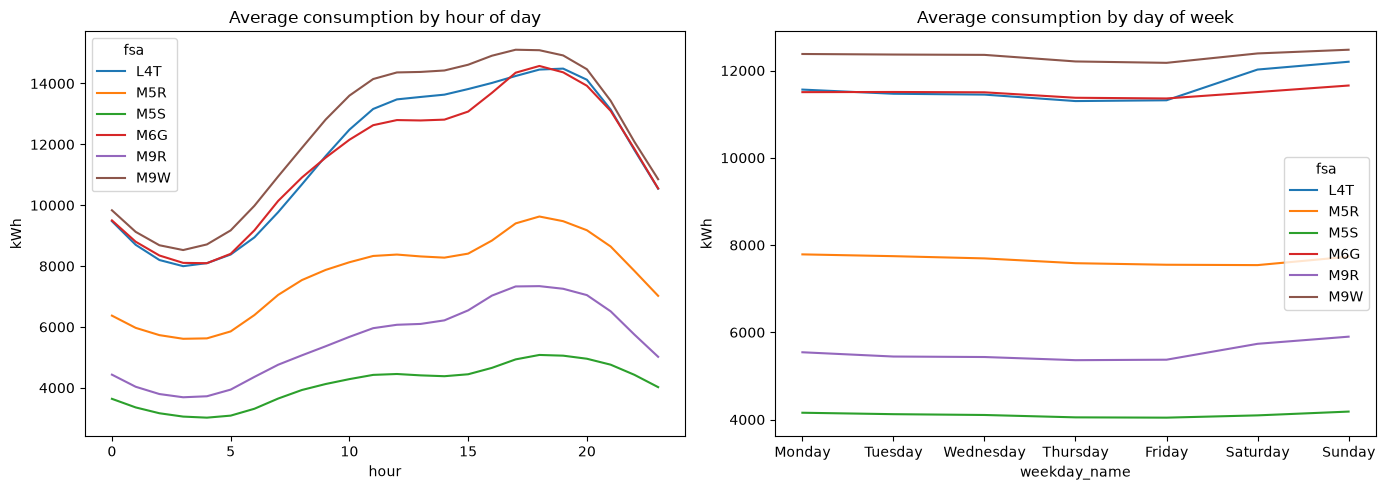

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dataset.groupby(["fsa", "hour"])["electricity_consumption"].mean().unstack("fsa").plot(
    ax=axes[0], title="Average consumption by hour of day"
)
axes[0].set_ylabel("kWh")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dataset.groupby(["fsa", "weekday_name"])["electricity_consumption"].mean().unstack(
    "fsa"
).reindex(weekday_order).plot(ax=axes[1], title="Average consumption by day of week")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.show()

In [93]:
dataset.groupby(["fsa", "season"])["electricity_consumption"].mean().unstack("season")

season,Fall,Spring,Summer,Winter
fsa,,,,
L4T,10404.208645,10298.983687,14021.925353,11735.896960
M5R,6709.548425,6875.077600,8067.281558,9012.304056
M5S,3712.611722,3742.383705,4183.585344,4805.750148
M6G,10054.953984,10384.202554,12445.035842,13083.922044
M9R,4863.196282,4799.539511,6801.599284,5699.404684
M9W,11041.642656,11165.298976,14193.341721,12947.216011


Both tiers follow the same daily shape as before: a dip around 3-5am, a peak around 17-19h. On
weekdays, L4T and M9W rise noticeably from Friday to Sunday (~11,400 to 12,500 kWh); M6G stays
flat all week.

Seasonality splits by station, not tier: the airport FSAs (L4T, M9R, M9W) peak in Summer, the
downtown FSAs (M5R, M5S, M6G) peak in Winter instead (L4T +35% Fall to Summer, M6G +30% Fall to
Winter). Same tier doesn't mean same peak season.

## 5. Investigating the two-tier consumption split

The previous notebook flagged a high/low consumption tier split (L4T, M6G, M9W vs M5R, M9R,
M5S) without explaining it. The only variables available to test are `premise_count` and
`station`, no zone-type column exists.

`consumption_per_premise` below checks whether it's just about how many premises each FSA has,
or something behavioral beyond that.

In [94]:
tier_summary = dataset.groupby("fsa").agg(
    mean_consumption=("electricity_consumption", "mean"),
    mean_premise_count=("premise_count", "mean"),
).sort_values("mean_consumption", ascending=False)
tier_summary["consumption_per_premise"] = (
    tier_summary["mean_consumption"] / tier_summary["mean_premise_count"]
)
tier_summary

,mean_consumption,mean_premise_count,consumption_per_premise
fsa,,,
M9W,12337.413226,10484.215567,1.176761
L4T,11617.975148,8594.852250,1.351736
M6G,11488.117506,11907.738933,0.964761
M5R,7662.036624,9373.594606,0.817406
M9R,5542.009675,6000.019419,0.923665
M5S,4108.749952,5924.354920,0.693535


Consumption per premise doesn't converge (0.69-0.92 low tier, 0.96-1.35 high tier), so it's not
just premise count. M6G is high tier through density; L4T and M9W through intensity, fewer
premises using more each, likely commercial/industrial near Pearson.

## 6. Consumption vs. weather correlation

Pearson and Spearman correlation against `electricity_consumption`, to document evidence for
feature engineering later, not to decide what stays. Correlation only catches linear
relationships; LightGBM finds non-linear splits a coefficient won't show, so a low value here
isn't grounds to drop anything.

In [95]:
temperature_correlation = {
    "pearson": dataset["temperature_c"].corr(dataset["electricity_consumption"]),
    "spearman": dataset["temperature_c"].corr(
        dataset["electricity_consumption"], method="spearman"
    ),
}
humidity_correlation = {
    "pearson": dataset["relative_humidity_pct"].corr(dataset["electricity_consumption"]),
    "spearman": dataset["relative_humidity_pct"].corr(
        dataset["electricity_consumption"], method="spearman"
    ),
}
pd.DataFrame(
    {"temperature_c": temperature_correlation, "relative_humidity_pct": humidity_correlation}
)

,temperature_c,relative_humidity_pct
pearson,0.081004,-0.105444
spearman,0.032302,-0.099466


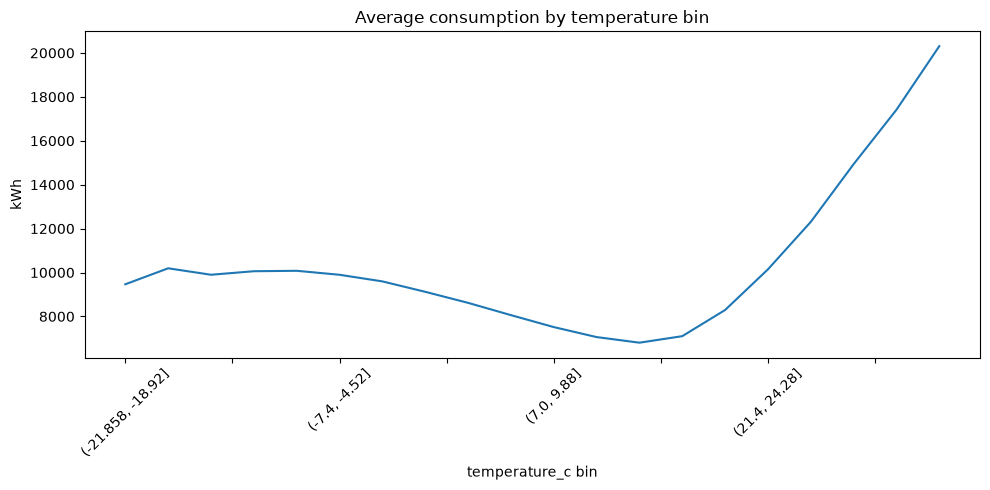

In [96]:
temperature_bins = pd.cut(dataset["temperature_c"], bins=20)
dataset.groupby(temperature_bins, observed=False)["electricity_consumption"].mean().plot(
    figsize=(10, 5), title="Average consumption by temperature bin"
)
plt.xlabel("temperature_c bin")
plt.ylabel("kWh")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pearson (0.081) and Spearman (0.032) both look near zero, but the bin plot shows a clear
U-shape instead: a minimum around 7-18 C, climbing to ~9,500 kWh at -20 C and past 20,000 kWh at
the warmest bins, cooling much steeper than heating. Temperature is a strong predictor, just not
a linear one.

`precipitation_mm`, `wind_speed_kmh`, and `visibility_km` only exist for one station each, so
correlation has to be computed within that station's rows, not on the full dataset.

In [97]:
toronto_city = dataset.loc[dataset["station"] == "toronto_city"]
toronto_intl_a = dataset.loc[dataset["station"] == "toronto_intl_a"]

station_variable_correlation = pd.Series(
    {
        "precipitation_mm (toronto_city)": toronto_city["precipitation_mm"].corr(
            toronto_city["electricity_consumption"]
        ),
        "wind_speed_kmh (toronto_intl_a)": toronto_intl_a["wind_speed_kmh"].corr(
            toronto_intl_a["electricity_consumption"]
        ),
        "visibility_km (toronto_intl_a)": toronto_intl_a["visibility_km"].corr(
            toronto_intl_a["electricity_consumption"]
        ),
    },
    name="pearson_correlation",
)
station_variable_correlation.to_frame()

,pearson_correlation
precipitation_mm (toronto_city),0.002963
wind_speed_kmh (toronto_intl_a),0.111686
visibility_km (toronto_intl_a),0.002785


`precipitation_mm` and `visibility_km` come out at zero (0.003 each); `wind_speed_kmh` is weak
but not zero (0.112). None look like strong predictors alone, though that only rules out a
linear relationship.

Same idea, but all seven variables against each other at once, including `premise_count`.
Pandas drops NaN rows pairwise, so precipitation/wind/visibility still end up compared only
within their own station.

In [98]:
correlation_columns = [
    "temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "wind_speed_kmh",
    "visibility_km",
    "premise_count",
    "electricity_consumption",
]
correlation_matrix = dataset[correlation_columns].corr()
correlation_matrix

,temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,visibility_km,premise_count,electricity_consumption
temperature_c,1.000000,-0.166825,0.002526,-0.140894,0.146302,0.001302,0.081004
relative_humidity_pct,-0.166825,1.000000,0.215107,-0.207759,-0.462048,-0.012792,-0.105444
precipitation_mm,0.002526,0.215107,1.000000,NaN,NaN,0.000359,0.002963
wind_speed_kmh,-0.140894,-0.207759,NaN,1.000000,0.043716,0.001067,0.111686
visibility_km,0.146302,-0.462048,NaN,0.043716,1.000000,-0.004338,0.002785
premise_count,0.001302,-0.012792,0.000359,0.001067,-0.004338,1.000000,0.664477
electricity_consumption,0.081004,-0.105444,0.002963,0.111686,0.002785,0.664477,1.000000


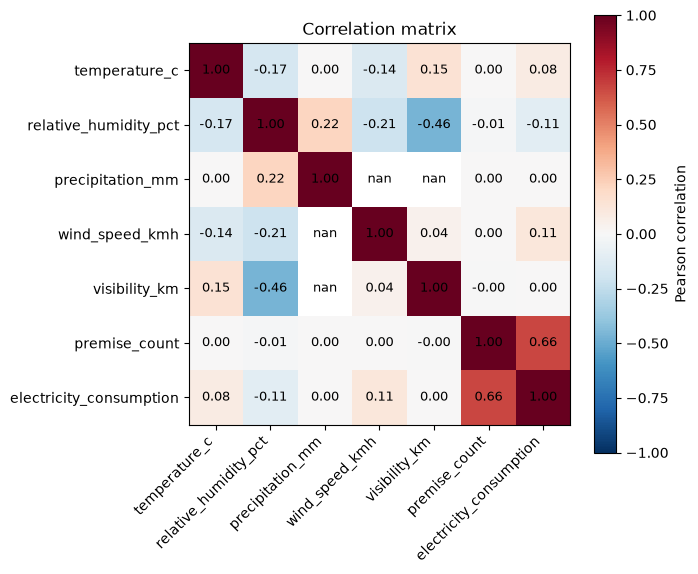

In [99]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        ax.text(
            j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9
        )
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

`relative_humidity_pct` vs `visibility_km` is moderately negative (-0.46), humid air reduces
visibility, as expected. `precipitation_mm` vs `wind_speed_kmh`/`visibility_km` shows NaN, not
weak, they never coexist in the same row (different stations).

`premise_count` vs `electricity_consumption` is the strongest in the matrix (0.66), but
expected: consumption is a sum per FSA-hour, so more premises mechanically means more total,
the same density effect from section 5, just quantified. Not evidence it'd be a strong feature
on its own, `fsa` already captures per-FSA differences.

## 7. Where peaks fall: a first look at percentile thresholds

Exploratory only: P95, P97.5, and P99 of `electricity_consumption` per FSA and season, to see
roughly where thresholds fall. Not the modeling threshold, that one is computed per fold, on
training data only.

In [100]:
peak_percentiles = (
    dataset.groupby(["fsa", "season"])["electricity_consumption"]
    .quantile([0.95, 0.975, 0.99])
    .unstack()
)
peak_percentiles.columns = ["p95", "p975", "p99"]
peak_percentiles

p95        p975        p99
fsa season                                  
L4T Fall    14859.830  16207.3000  17882.896
    Spring  13681.525  14568.3225  15908.296
    Summer  22585.910  23822.3750  25178.482
    Winter  15105.285  15546.2225  16108.650
M5R Fall     9275.725   9800.8225  10533.815
    Spring   9468.820  10006.9950  10673.838
    Summer  12202.205  13102.3525  13954.865
    Winter  11972.870  12488.2125  13047.820
M5S Fall     5037.415   5295.3075   5628.596
    Spring   5106.355   5386.4050   5675.044
    Summer   6003.015   6356.2625   6688.976
    Winter   6325.470   6583.9950   6882.572
M6G Fall    14226.365  14973.6100  15991.827
    Spring  14444.185  15102.6375  15917.742
    Summer  19488.985  21037.0050  22979.755
    Winter  17099.410  17807.2250  18408.716
M9R Fall     7191.995   7830.4900   8928.239
    Spring   6670.505   7050.0075   7842.287
    Summer  11931.460  12841.0225  13834.142
    Winter   7682.455   7968.4000   8259.071
M9W Fall    16959.080  18070.0425  20020.491
    Spring  16424.255  16961.9425  17587.871
    Summer  24479.340  26843.3275  28931.366
    Winter  18257.160  18704.1650  19221.202

Five of six FSAs peak in Summer (M9W's P99: 19,221 Winter to 28,931 Summer). M5S is the
exception, slightly higher in Winter across all three levels, matching its Winter-leaning
average. Either way, a global threshold would misread someone's normal as someone else's
extreme, confirming the per-FSA-and-season threshold already locked in for modeling.

## 8. Save the cleaned dataset

Saves the interpolated dataset to `data/interim/fsa_hourly_master_clean.parquet`, separate from
the raw join output in `fsa_hourly_master.parquet`, so we don't have to rerun the cleaning steps
above every time we need a clean copy to work from.

In [101]:
output_path = save_interim_dataset(dataset, filename="fsa_hourly_master_clean.parquet")
output_path

WindowsPath('C:/workspace/CAPSTONE/ontario-electricity-peak-risk/data/interim/fsa_hourly_master_clean.parquet')